# 04-01 - Exploratory Data Analysis (EDA)

**Phase:** 04 - Data Analysis & Preparation

**Difficulty:** 1/3 | **Priority:** 1/2

**Status:** VERIFIED

---

## 1. What Are We Solving?

**Exploratory Data Analysis (EDA)** is the process of understanding a dataset before modeling: summary statistics, distributions, correlations, and visualizations. It answers 'what does this data look like?' and reveals patterns, problems, and insights.

## 2. Why Does This Matter?

EDA is the first and most important step in any ML project. It helps you find data quality issues, understand feature relationships, and make informed modeling decisions. Skipping EDA leads to bad models built on misunderstood data.

## 3. Prerequisites

- Phase 03 (Statistics & Probability)
- Phase 01 (Python Foundations)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- [ ] Load and inspect a dataset
- [ ] Compute summary statistics
- [ ] Visualize distributions and relationships
- [ ] Build a correlation matrix
- [ ] Identify patterns and potential issues
## 5. Mental Model

**Mental Model:** Think of EDA like being a detective at a crime scene. Before you write a single report, you walk the scene: you look around (inspect), take photos (visualize), collect evidence (compute statistics), and piece together what happened (analyze). You wouldn't start a trial without doing this — and you shouldn't start modeling without doing EDA.

Key: understand the data before you model it.


## 2a. Decision Guidance

| Situation | What to Do | Why |
|-----------|------------|-----|
| Dataset has >30 features | Use correlation heatmap first | Find redundant features early |
| Target is imbalanced | Check `value_counts()` on target | Plan resampling strategy |
| Numeric features vary in scale | Look at min/max/median | Decide on scaling later |
| Distributions are highly skewed | Note which features need transforms | Plan log/box-cox transforms |
| Categories have many levels | Flag high-cardinality features | Plan encoding strategy |


## 2b. Common Mistakes to Avoid

- Skipping EDA and going straight to modeling
- Only looking at mean (ignore median, std, min/max)
- Not checking the target variable distribution
- Ignoring correlation matrix (miss multicollinearity)
- Forgetting to check data types and missing values


## 6. Load and Inspect the Dataset

We'll use a synthetic customer dataset with numeric and categorical features.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 500

df = pd.DataFrame({
    "age": np.random.randint(18, 70, n),
    "income": np.random.normal(60000, 20000, n),
    "spend": np.random.normal(3000, 1000, n),
    "visits": np.random.poisson(5, n),
    "region": np.random.choice(["North", "South", "East", "West"], n),
    "churned": np.random.choice([0, 1], n, p=[0.7, 0.3]),
})

# Inspect
print("First 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nDataset shape:", df.shape)


First 5 rows:
   age         income        spend  visits region  churned
0   56  102443.123940  2024.126747       8   East        0
1   69   80649.305211  4053.641797       3  South        1
2   46   29612.600681  2050.601111       4   East        0
3   32   50315.318543  5632.382065       7   West        1
4   60   85338.222984  3493.317901       8   East        0

Dataset info:


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      500 non-null    int32  
 1   income   500 non-null    float64
 2   spend    500 non-null    float64
 3   visits   500 non-null    int32  
 4   region   500 non-null    str    
 5   churned  500 non-null    int64  
dtypes: float64(2), int32(2), int64(1), str(1)
memory usage: 21.9 KB
None

Dataset shape: (500, 6)


## 7. Summary Statistics

`describe()` gives count, mean, std, min, quartiles, and max for numeric columns.


In [2]:
# Summary statistics
print(df.describe())
print("\n--- Categorical columns ---")
print(df["region"].value_counts())
print("\n--- Missing values ---")
print(df.isnull().sum())


              age         income        spend      visits     churned
count  500.000000     500.000000   500.000000  500.000000  500.000000
mean    44.220000   59410.340587  3127.981398    4.970000    0.300000
std     15.036082   19875.294583   988.667247    2.276723    0.458717
min     18.000000   -4825.346801   103.744622    0.000000    0.000000
25%     32.000000   45715.092154  2444.019214    3.000000    0.000000
50%     45.000000   59549.733189  3125.400478    5.000000    0.000000
75%     57.000000   72573.326849  3749.422322    6.000000    1.000000
max     69.000000  121577.616169  5632.382065   12.000000    1.000000

--- Categorical columns ---
region
South    136
East     132
North    121
West     111
Name: count, dtype: int64

--- Missing values ---
age        0
income     0
spend      0
visits     0
region     0
churned    0
dtype: int64


## 8. Distribution of Numeric Features

Histograms show the shape of each numeric feature's distribution.


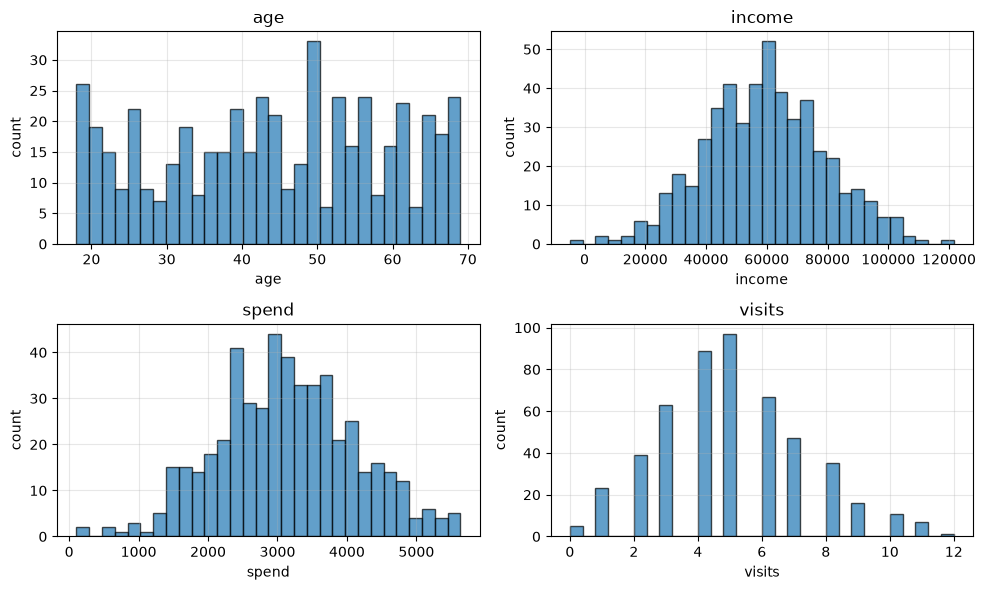

Income and spend look roughly normal; visits is Poisson-like (count data).


In [3]:
# Histograms of numeric features
numeric_cols = ["age", "income", "spend", "visits"]
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(df[col], bins=30, alpha=0.7, edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Income and spend look roughly normal; visits is Poisson-like (count data).")


## 9. Categorical Distribution

Bar plots show the frequency of each category.


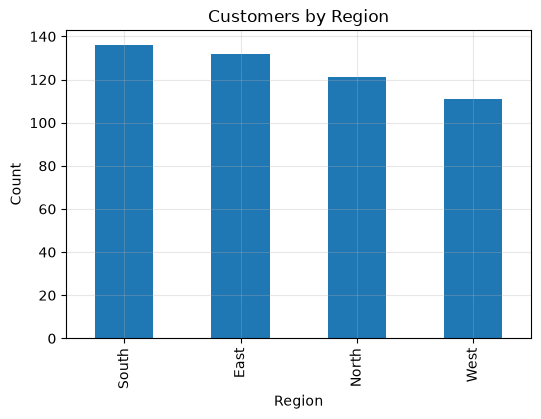

Regions are roughly balanced.


In [4]:
# Bar plot of region
plt.figure(figsize=(6, 4))
df["region"].value_counts().plot(kind="bar")
plt.title("Customers by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()
print("Regions are roughly balanced.")


## 10. Correlation Matrix

A correlation matrix shows how numeric features relate to each other and to the target.


              age    income     spend    visits   churned
age      1.000000  0.021506 -0.039117  0.008155  0.012203
income   0.021506  1.000000 -0.018741 -0.042705  0.065672
spend   -0.039117 -0.018741  1.000000 -0.000243  0.024176
visits   0.008155 -0.042705 -0.000243  1.000000 -0.022067
churned  0.012203  0.065672  0.024176 -0.022067  1.000000


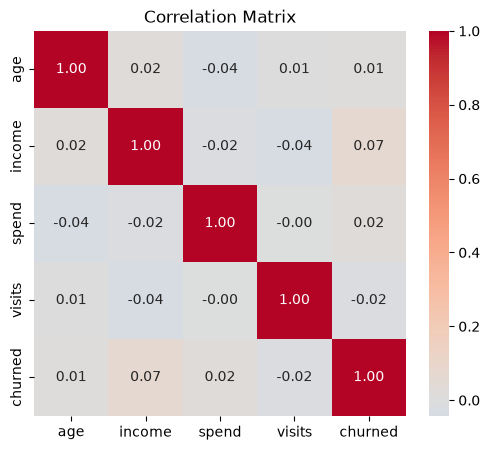


Look for strong correlations between features and with the target (churned).


In [5]:
# Correlation matrix
corr = df[numeric_cols + ["churned"]].corr()
print(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Matrix")
plt.show()
print("\nLook for strong correlations between features and with the target (churned).")


## 11. Relationships: Scatter Plots

Scatter plots reveal relationships between two numeric features.


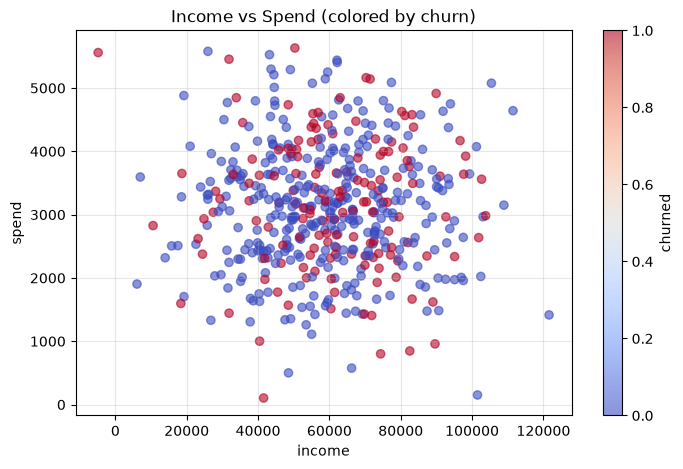

Higher spend tends to correlate with higher income.


In [6]:
# Scatter plot: income vs spend, colored by churn
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df["income"], df["spend"], c=df["churned"], cmap="coolwarm", alpha=0.6)
plt.colorbar(scatter, label="churned")
plt.xlabel("income")
plt.ylabel("spend")
plt.title("Income vs Spend (colored by churn)")
plt.grid(True, alpha=0.3)
plt.show()
print("Higher spend tends to correlate with higher income.")


## 12. Boxplots for Group Comparison

Boxplots compare distributions across categories.


<Figure size 800x500 with 0 Axes>

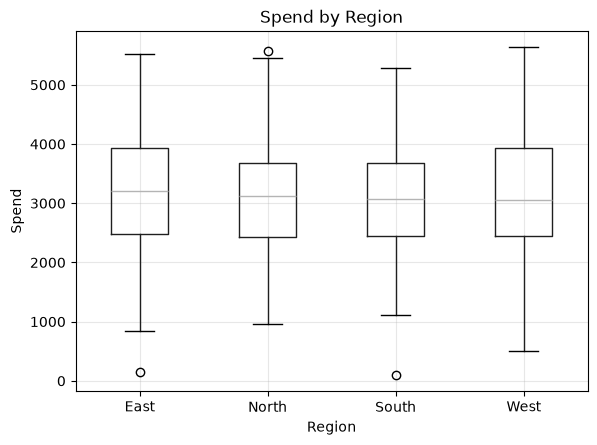

Boxplots show median, quartiles, and outliers for each region.


In [7]:
# Boxplot: spend by region
plt.figure(figsize=(8, 5))
df.boxplot(column="spend", by="region")
plt.title("Spend by Region")
plt.suptitle("")
plt.xlabel("Region")
plt.ylabel("Spend")
plt.grid(True, alpha=0.3)
plt.show()
print("Boxplots show median, quartiles, and outliers for each region.")


## 13. Failure Case: Skipping EDA

If you skip EDA, you might miss critical issues: missing values, outliers, imbalanced classes, or strong correlations that break assumptions.


In [8]:
# Demonstrate why EDA matters: imbalanced target
print("Churn distribution:")
print(df["churned"].value_counts(normalize=True))
print("\nOnly ~30% churned. If we don't notice this, accuracy can be misleading.")
print("EDA reveals the imbalance before we build a model.")


Churn distribution:
churned
0    0.7
1    0.3
Name: proportion, dtype: float64

Only ~30% churned. If we don't notice this, accuracy can be misleading.
EDA reveals the imbalance before we build a model.


## 14. Debugging: Common Errors

- **Not checking data types**: strings vs numbers cause errors.
- **Ignoring missing values**: models fail or silently misbehave.
- **Not visualizing**: summary stats hide outliers and shapes.
- **Imbalanced target**: accuracy is misleading.
- **Correlated features**: multicollinearity destabilizes models.

## 15. Real-World Considerations

- EDA is iterative - you'll revisit it as you learn more.
- Use both summary stats AND visualizations.
- Document findings - they guide modeling decisions.
- Check for data quality issues early.

## 16. Common Mistakes

- Relying only on `describe()` without plotting.
- Ignoring categorical variables.
- Not checking the target distribution.
- Building models before understanding the data.

## 17. When NOT to Use

- Don't over-analyze - EDA should guide, not replace, modeling.
- Don't draw causal conclusions from correlations.
- Don't ignore domain knowledge.

## 18. Challenge

Find which numeric feature correlates most strongly with churn, and identify any feature with a skewed distribution.


In [9]:
# Challenge: strongest correlation with churn + skewed feature
corr_with_target = df[numeric_cols].corrwith(df["churned"])
strongest = corr_with_target.abs().idxmax()
print("Correlation of each feature with churn:")
print(corr_with_target)
print(f"\nStrongest correlation with churn: {strongest} ({corr_with_target[strongest]:.3f})")

# Skewness of each numeric feature
from scipy import stats
print("\nSkewness of each feature:")
for col in numeric_cols:
    print(f"  {col}: {stats.skew(df[col]):.3f}")
print("\nFeatures with |skew| > 1 are highly skewed and may need transformation.")


Correlation of each feature with churn:
age       0.012203
income    0.065672
spend     0.024176
visits   -0.022067
dtype: float64

Strongest correlation with churn: income (0.066)

Skewness of each feature:
  age: -0.112
  income: 0.040
  spend: 0.023
  visits: 0.362

Features with |skew| > 1 are highly skewed and may need transformation.


## 19. Knowledge Check

1. What does `df.describe()` show, and what can you learn from it that `df.head()` cannot tell you?
2. Why is a correlation matrix useful? What range of values indicates strong correlation?
3. What does a boxplot reveal that a histogram does not?
4. Why is EDA important before modeling? What happens if you skip it?
5. How would you detect an imbalanced target variable?

## 20. Teach-Back Questions

Explain to another person:

- How you would explore a brand-new dataset.
- Why visualizations matter in addition to summary statistics.
- How a correlation matrix guides feature selection.

## 21. Summary

You now know how to explore a dataset: inspect it, compute summary statistics, visualize distributions and relationships, and build correlation matrices. EDA is the essential first step in any data project.


## 21a. Exit Criteria

- [ ] I can load a dataset and inspect its structure
- [ ] I can compute and interpret summary statistics
- [ ] I can create histograms, boxplots, and scatter plots
- [ ] I can build and interpret a correlation matrix
- [ ] I can identify data quality issues from EDA

## 21b. Next Step

Proceed to `04_02_data_cleaning.ipynb` to learn how to fix the issues EDA reveals.

## 22. Hands-On Practice

**Level 1 - Observation:** Run `df.head()`, `df.info()`, `df.describe()` and read the output.

**Level 2 - Guided:** Create a histogram of the first numeric column using matplotlib.

**Level 3 - Practice:** Build a correlation heatmap with seaborn, annotating values.

**Level 4 - Challenge:** Identify the 3 most correlated feature pairs and explain what they mean.

**Level 5 - Mastery:** Create a data quality report summarizing dtypes, missing values, outliers, and distributions in one view.

## 23. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, pandas, matplotlib, seaborn, scipy
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
